In [6]:
# ============================================
# CELL 1: LOAD DATA + STRIP COLUMN NAMES
# ============================================

import pandas as pd
import numpy as np

df = pd.read_csv("Heart_Prediction.csv")

print("Initial shape:", df.shape)

# Strip spaces from column names (good practice)
df.columns = df.columns.str.strip()

print("\nColumn names after strip:")
print(df.columns.tolist())

df.head()


Initial shape: (1016, 12)

Column names after strip:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,66,M,NAP,116,100,0,ST,122,N,0.6,Up,0
1,41,M,ATA,117,239,0,ST,148,N,2.0,Up,0
2,32,M,ASY,118,100,1,Normal,135,Y,1.2,Flat,1
3,51,F,ATA,115,400,0,Normal,140,N,0.0,Up,0
4,56,M,NAP,152,123,1,Normal,174,N,0.2,Up,0


In [7]:
# ============================================
# CELL 2: STRIP SPACES IN STRING/CATEGORICAL VALUES
# ============================================

# Find object (string) columns
obj_cols = df.select_dtypes(include="object").columns.tolist()
print("Object columns:", obj_cols)

# Strip leading/trailing spaces inside text columns
for col in obj_cols:
    df[col] = df[col].astype(str).str.strip()

print("\nSample unique values after stripping (first few):")
for col in obj_cols:
    print(col, "->", df[col].unique()[:5])


Object columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Sample unique values after stripping (first few):
Sex -> ['M' 'F']
ChestPainType -> ['NAP' 'ATA' 'ASY' 'TA']
RestingECG -> ['ST' 'Normal' 'LVH']
ExerciseAngina -> ['N' 'Y']
ST_Slope -> ['Up' 'Flat' 'Down']


In [8]:
# ============================================
# CELL 3: CHECK NULL / MISSING VALUES
# ============================================

missing_per_col = df.isnull().sum().sort_values(ascending=False)
total_missing = missing_per_col.sum()

print("Missing values per column:\n", missing_per_col)
print("\nTotal missing values:", total_missing)


Missing values per column:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Total missing values: 0


In [9]:
# ============================================
# CELL 4: HANDLE MISSING VALUES (IF ANY)
# Strategy:
# - Numeric -> median
# - Categorical -> mode
# ============================================

shape_before = df.shape
total_missing_before = df.isnull().sum().sum()

if total_missing_before > 0:
    # Numeric columns: fill with median
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    for col in num_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    # Categorical columns: fill with mode
    for col in obj_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])

total_missing_after = df.isnull().sum().sum()

print("Shape before missing handling:", shape_before)
print("Shape after missing handling :", df.shape)
print("Total missing BEFORE:", total_missing_before)
print("Total missing AFTER :", total_missing_after)


Shape before missing handling: (1016, 12)
Shape after missing handling : (1016, 12)
Total missing BEFORE: 0
Total missing AFTER : 0


In [10]:
# ============================================
# CELL 5: DUPLICATE CHECK + REMOVE
# ============================================

dup_count = df.duplicated().sum()
print("Duplicate rows found:", dup_count)

shape_before = df.shape
df = df.drop_duplicates()
shape_after = df.shape

print("Shape before removing duplicates:", shape_before)
print("Shape after removing duplicates :", shape_after)


Duplicate rows found: 0
Shape before removing duplicates: (1016, 12)
Shape after removing duplicates : (1016, 12)


In [12]:
# ============================================
#  BASIC EDA
# ============================================

# Dataset shape
print("Dataset shape:", df.shape)

# Check missing values
print("\nTotal missing values:", df.isnull().sum().sum())

# Numerical summary
print("\nNumerical feature summary:")
display(df.describe().T)

# Target distribution
print("\nTarget (HeartDisease) distribution:")
print(df["HeartDisease"].value_counts())

print("\nTarget proportion:")
print(df["HeartDisease"].value_counts(normalize=True))


Dataset shape: (1016, 12)

Total missing values: 0

Numerical feature summary:


,count,mean,std,min,25%,50%,75%,max
Age,1016.0,52.335630,9.842431,23.0,46.0,53.00,59.0,80.0
RestingBP,1016.0,131.947835,18.586828,80.0,119.0,131.00,142.0,200.0
Cholesterol,1016.0,216.875984,74.136888,100.0,172.0,224.00,267.0,400.0
FastingBS,1016.0,0.217520,0.412762,0.0,0.0,0.00,0.0,1.0
MaxHR,1016.0,137.850394,26.388893,60.0,119.0,139.00,156.0,204.0
Oldpeak,1016.0,0.818012,1.003197,0.0,0.0,0.45,1.5,6.2
HeartDisease,1016.0,0.500000,0.500246,0.0,0.0,0.50,1.0,1.0



Target (HeartDisease) distribution:
HeartDisease
0    508
1    508
Name: count, dtype: int64

Target proportion:
HeartDisease
0    0.5
1    0.5
Name: proportion, dtype: float64


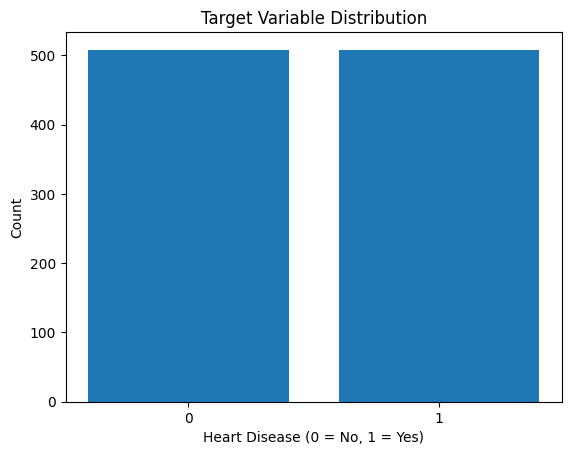

In [13]:
# ============================================
# PLOT 1: TARGET DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt

plt.figure()
counts = df["HeartDisease"].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)

plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Target Variable Distribution")

plt.show()


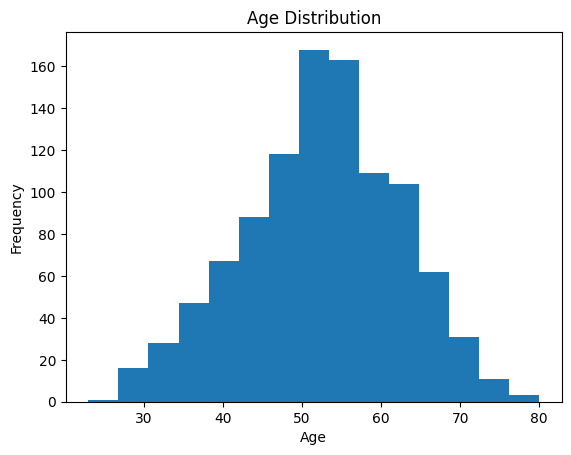

In [14]:
# ============================================
# PLOT 2: AGE DISTRIBUTION
# ============================================

plt.figure()
plt.hist(df["Age"], bins=15)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()


/tmp/ipython-input-3695809612.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([age_no, age_yes],


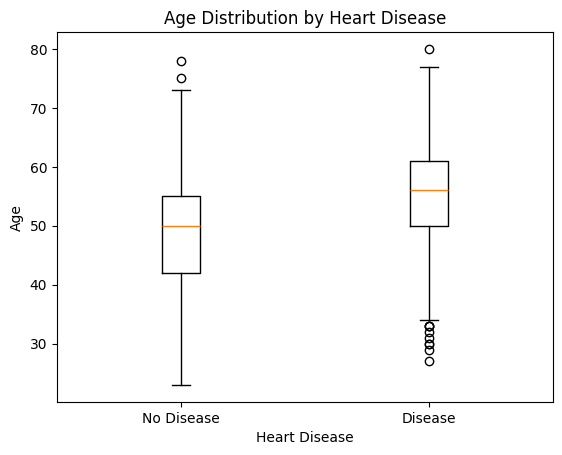

In [15]:
# ============================================
# PLOT 3: AGE vs HEART DISEASE
# ============================================

plt.figure()

age_no = df[df["HeartDisease"] == 0]["Age"]
age_yes = df[df["HeartDisease"] == 1]["Age"]

plt.boxplot([age_no, age_yes],
            labels=["No Disease", "Disease"])

plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.title("Age Distribution by Heart Disease")

plt.show()


Numeric columns used in correlation:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']


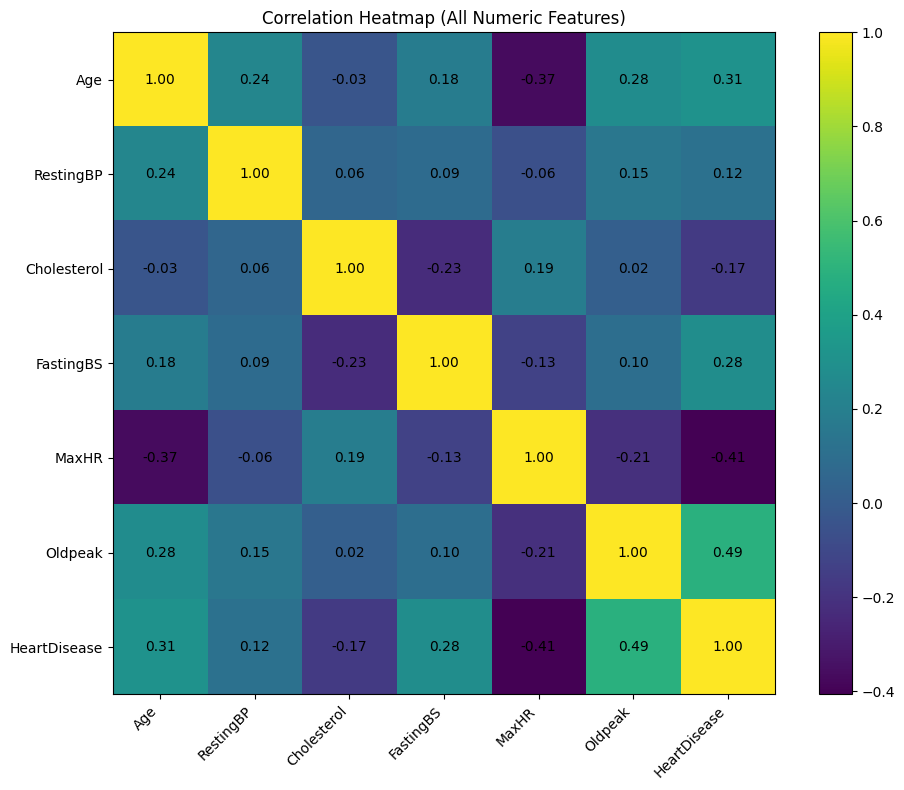

In [18]:
# ============================================
# CORRELATION HEATMAP
# ============================================

import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

print("Numeric columns used in correlation:")
print(numeric_df.columns.tolist())

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar()

# Axis ticks and labels
plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

# Annotate correlation values
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center", va="center"
        )

plt.title("Correlation Heatmap (All Numeric Features)")
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

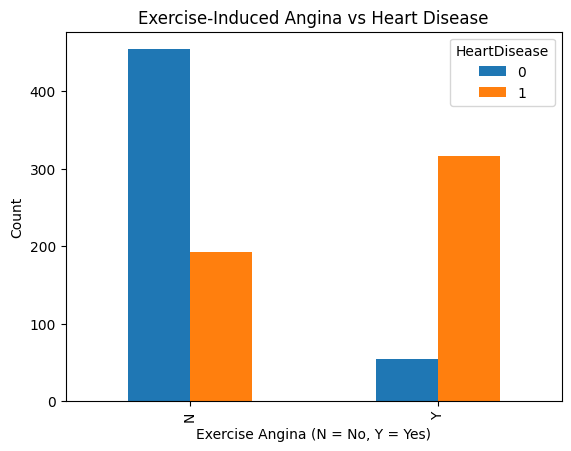

In [17]:
# ============================================
# PLOT 5: EXERCISE ANGINA vs HEART DISEASE
# ============================================

plt.figure()

angina_hd = df.groupby(["ExerciseAngina", "HeartDisease"]).size().unstack()
angina_hd.plot(kind="bar")

plt.xlabel("Exercise Angina (N = No, Y = Yes)")
plt.ylabel("Count")
plt.title("Exercise-Induced Angina vs Heart Disease")
plt.legend(title="HeartDisease")

plt.show()
